In [11]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [12]:
dataset_path = "/content/flowers"

In [13]:
images = []
labels = []

IMG_SIZE = (64,64)

for folder in os.listdir(dataset_path):

    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):

        for file in tqdm(os.listdir(folder_path), desc=folder):

            try:

                img = Image.open(os.path.join(folder_path,file)).convert("RGB")

                img = img.resize(IMG_SIZE)

                img = np.array(img)

                images.append(img)

                labels.append(folder)

            except:
                pass

print("Jumlah gambar :",len(images))

rose: 100%|██████████| 784/784 [00:02<00:00, 310.75it/s]

Jumlah gambar : 4317


In [14]:
images = np.array(images,dtype="float32")/255.0
labels = np.array(labels)

X = images.reshape(images.shape[0],-1)

encoder = LabelEncoder()

y = encoder.fit_transform(labels)

print(X.shape)

(4317, 12288)


In [15]:
pca = PCA(n_components=200, random_state=24146031)

X = pca.fit_transform(X)

print(X.shape)

(4317, 200)


In [16]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=24146031
)

print(X_train.shape)
print(X_test.shape)

(3453, 200)
(864, 200)


In [17]:
mlp = MLPClassifier(
    hidden_layer_sizes=(32,),
    activation="relu",
    solver="adam",
    max_iter=30,
    early_stopping=True,
    random_state=24146031
)

In [18]:
mlp.fit(X_train,y_train)

print("Training selesai")

Training selesai


In [19]:
y_pred=mlp.predict(X_test)

In [20]:
accuracy=accuracy_score(y_test,y_pred)

print("Accuracy :",accuracy)

Accuracy : 0.45023148148148145


In [21]:
print(classification_report(
    y_test,
    y_pred,
    target_names=encoder.classes_,
    digits=4
))

              precision    recall  f1-score   support

       daisy     0.3819    0.3595    0.3704       153
   dandelion     0.4359    0.4857    0.4595       210
        rose     0.4532    0.4013    0.4257       157
   sunflower     0.5694    0.5578    0.5636       147
       tulip     0.4286    0.4416    0.4350       197

    accuracy                         0.4502       864
   macro avg     0.4538    0.4492    0.4508       864
weighted avg     0.4505    0.4502    0.4497       864



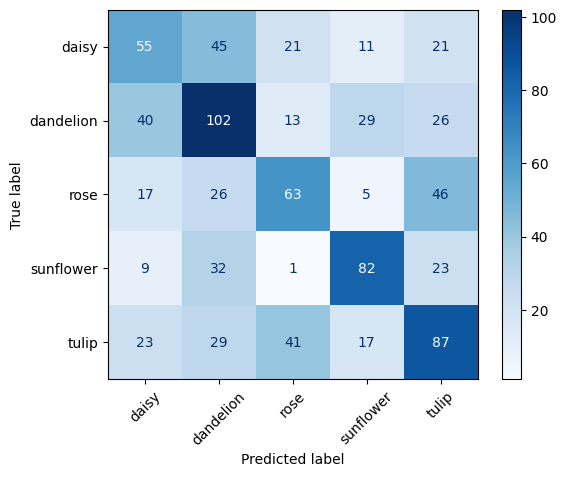

In [22]:
cm=confusion_matrix(y_test,y_pred)

disp=ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

disp.plot(cmap="Blues",xticks_rotation=45)

plt.show()

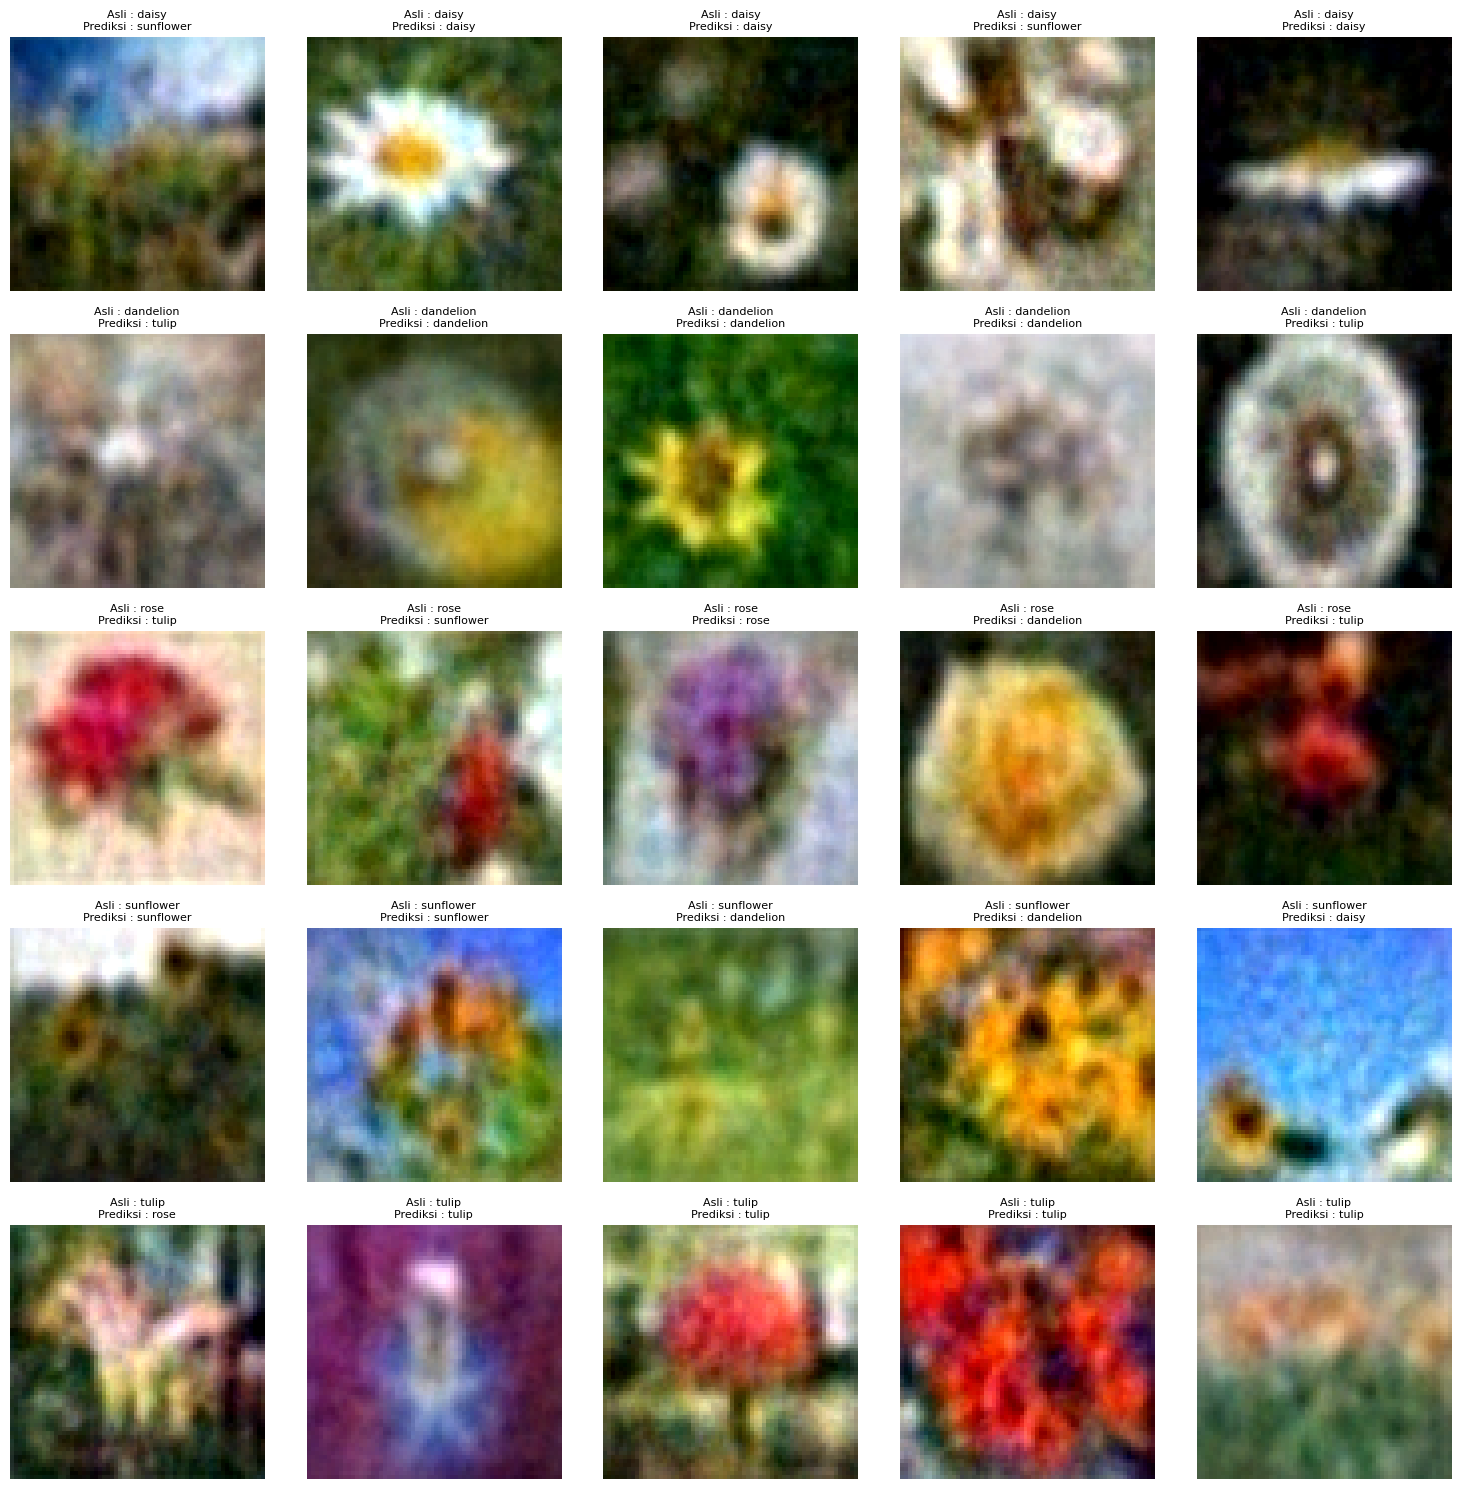

In [23]:
class_names = encoder.classes_

plt.figure(figsize=(15,15))

plot = 1

for kelas in range(len(class_names)):

    idx = np.where(y_test==kelas)[0]

    sample = random.sample(list(idx),5)

    for i in sample:

        plt.subplot(5,5,plot)

        img = pca.inverse_transform(X_test[i]).reshape(64,64,3)

        plt.imshow(np.clip(img,0,1))

        plt.title(
            f"Asli : {class_names[y_test[i]]}\nPrediksi : {class_names[y_pred[i]]}",
            fontsize=8
        )

        plt.axis("off")

        plot+=1

plt.tight_layout()

plt.show()